In [139]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from IPython.display import Latex, HTML, Math, display
from uncertainties import ufloat
from uncertainties.umath import sqrt
from uncertainties import unumpy as unp
from scipy.stats import linregress
from scipy.optimize import curve_fit
from uncertainties.umath import sin, radians 
from uncertainties.umath import *


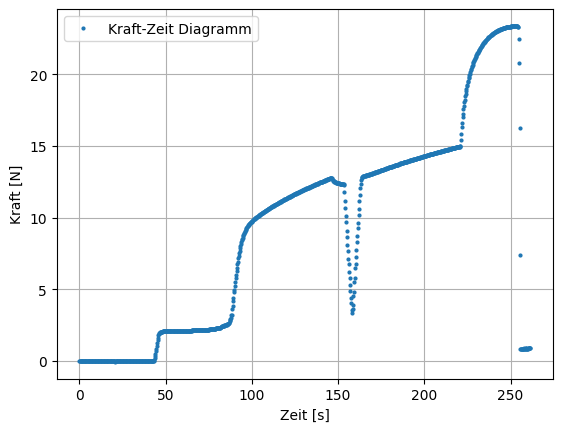

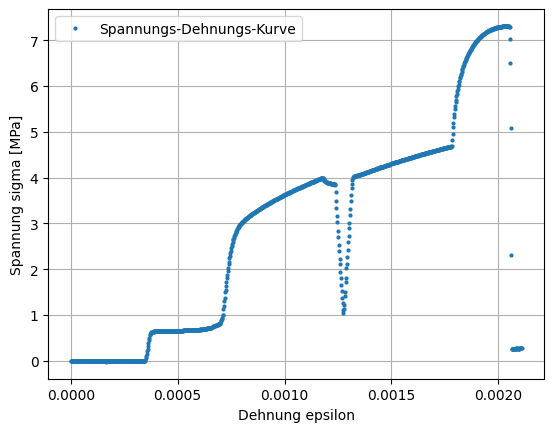

(6.99+/-0.11)e+04


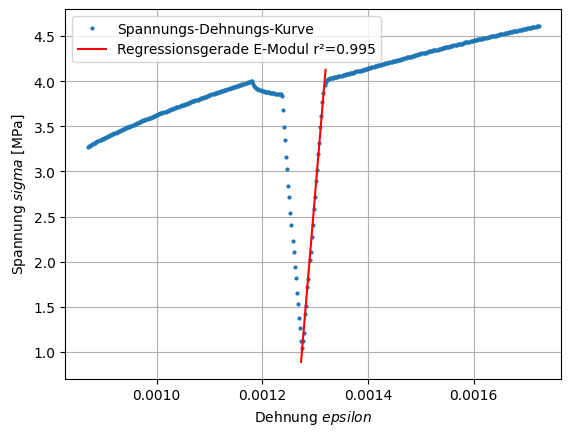

In [140]:
# 1. Experiment: Spannungs-Dehnungs-Kurve von Aluminium

#daten zugmaschine:
v = 0.05/60                 #[mm/min] --> [mm/s]
L0 = ufloat(103.35, 0.05)             #[mm]


#messung querschnitt draht
a = unp.uarray([2.02, 2.01, 2.02, 2.02, 2.02], 0.01)       #[mm?] unsicherheit 1?
d = np.mean(a)              #durchschnitt der werte [mm?]

q = (d/2)**2 * np.pi        #querschnitt [mm²?]

#umrechnungsfaktor
u =  1209                       #angezeigter Wert bei 1kg gewicht

#daten auslesen
df = pd.read_csv("PS1_Do01_SoSe26.csv", sep=",", decimal=".", engine="python")
t = df["T"].to_numpy()
wert = df["x"].to_numpy()

F = wert/u                  #messwert mit umrechnungsfaktor umgerechnet in Kraft [N]

#diagramm zeichnen
plt.figure()
plt.plot(t, F, 'o', markersize=2, label="Kraft-Zeit Diagramm")
plt.xlabel("Zeit [s]")
plt.ylabel("Kraft [N]")
plt.legend()
plt.grid(True)
plt.show()

#umrechnung spannung:
sigma = F/q                 #[MPa]

#umrechnung dehnung:
epsilon = (v * t)/unp.nominal_values(L0)        #einheitslos

#spannungs-dehnungs diagramm zeichnen
plt.figure()
plt.plot(unp.nominal_values(epsilon),unp.nominal_values(sigma), 'o', markersize=2, label="Spannungs-Dehnungs-Kurve")
plt.xlabel("Dehnung epsilon")
plt.ylabel("Spannung sigma [MPa]")
plt.legend()
plt.grid(True)
plt.show()

#Bestimmung E-Modul - 2. Anstieg!!
t_E = t[631:655]                 #eingeschränkt auf indizes wo der 2. Anstieg ist (aus Datensatz suchen)
wert_E = wert[631:655]

F_E = wert_E/u

sigma_E = F_E/q
epsilon_E = (v * t_E)/L0

slope, intercept, r, _, std = linregress(unp.nominal_values(epsilon_E), unp.nominal_values(sigma_E))

E_Modul = ufloat(slope, std)        #[MPa]
print(E_Modul)

#darstellung in eingeschränktem Bereich von Diagramm
plt.figure()
plt.plot(unp.nominal_values(epsilon[431:855]), unp.nominal_values(sigma[431:855]), 'o', markersize=2, label="Spannungs-Dehnungs-Kurve")          #epsilon und sigma sinnvoll einschränken
plt.plot(unp.nominal_values(epsilon_E), slope*unp.nominal_values(epsilon_E) + intercept, '-r', label=rf"Regressionsgerade E-Modul r²={r**2:.3f}")         #Regression
plt.xlabel("Dehnung $epsilon$")
plt.ylabel("Spannung $sigma$ [MPa]")
plt.legend()
plt.grid(True)
plt.show()

# #Bestimmung Streckgrenze - 1. Anstieg!!
# t_1 = t[,]                 #eingeschränkt auf indizes wo der 1. Anstieg ist (aus Datensatz suchen)
# wert_1 = wert[,]

# F_1 = wert_1/u

# sigma_1 = F_1/q
# epsilon_1 = (v * t_1)/L0

# reg1 = linregress(epsilon_1, sigma_1)           #linerare regression im 1. Anstieg
# plot_epslilon_1 = epsilon[,]


# t_2 = t[, ]                 #eingeschränkt auf bereich nach elastizitätsgrenze
# wert_2 = wert[, ]

# F_2 = wert_2/u

# sigma_2 = F_2/q
# epsilon_2 = (v * t_2)/L0

# reg2 = linregress(epsilon_2, sigma_2)
# plot_epslilon_2 = epsilon[, ]




# #plot elastizitätsgrenze - da fehlt noch was
# plt.figure()
# plt.plot(epsilon[,], sigma[,], 'o', markersize=2, label="Spannungs-Dehnungs-Kurve")          #epsilon und sigma sinnvoll einschränken
# plt.plot(plot_epslilon_1, reg1.slope*epsilon + reg1.intercept, '-r', label=rf"Regressionsgerade elastischer Teil r²={reg1.rvaluefloat**2:.3f}")      #epsilonwerte sinnvoll einschränken
# plt.plot(plot_epslilon_2, reg2.slope*epsilon + reg2.intercept, '-r', label=rf"Regressionsgerade plastischer Teil r²={reg2.rvaluefloat**2:.3f}")
# plt.plot(plot_epslilon_1 + 0.0005*plot_epslilon_1, reg1.slope*epsilon + reg1.intercept, '-g', label=rf"Regressionsgerade 0,05% Stredckgrenze r²={reg1.rvaluefloat**2:.3f}")
# plt.plot(plot_epslilon_1 + 0.002*plot_epslilon_1, reg1.slope*epsilon + reg1.intercept, '-b', label=rf"Regressionsgerade 0,2% Stredckgrenze r²={reg1.rvaluefloat**2:.3f}")
# plt.xlabel("Dehnung $\epsilon$")
# plt.ylabel("Spannung $\sigma$ [MPa]")
# plt.legend()
# plt.grid(True)
# plt.show()


In [141]:
# 2. Experiment: Bestimmung des Schubmoduls von Aluminium mit dem Torsionspendel

#messung Werte draht
a = (unp.uarray([3.03, 3.02, 3.02, 3.01, 3.02], 0.01))*10**(-3)      #[m] 
d = np.mean(a)              #durchschnitt der werte [m]
r = (d/2)

L = ufloat(0.651, 0.001)              #[m]

#abstände für messungen und massen
l1 = ufloat(0.050, 0.001)             #[m] mit oder ohne unsicherheit ??
l2 = ufloat(0.220, 0.001)             #[m]

m1 = (ufloat(249, 0.5))*10**(-3)          #[g]    #inkl aufhängung wiegen!!    
m2 = ufloat(373, 0.5)*10**(-3)           #[g]

#Bestimmung Schwingungsdauern m1:
T1_1_werte = unp.uarray([9.82, 9.70, 9.80, 9.73, 9.87, 9.65, 9.93, 8.90, 9.81, 9.84, 9.87], 0.01)/10     #[s]  #l1 
T1_1 = np.mean(T1_1_werte)

T1_2_werte = unp.uarray([19.78, 19.75, 19.46, 19.58, 19.48, 19.45, 19.58, 19.37, 19.43, 19.45], 0.01)/10     #[s]  #l2
T1_2 = np.mean(T1_2_werte)

#Bestimmung Schwingungsdauern m2:
T2_1_werte = unp.uarray([10.28, 10.05, 10.12, 10.10, 10.14, 10.21, 10.23, 10.26, 10.24, 10.28], 0.01)/10      #[s]  #l1
T2_1 = np.mean(T2_1_werte)

T2_2_werte = unp.uarray([22.89, 22.73, 22.80, 22.81, 22.84, 23.07, 22.98, 22.78, 23.07, 22.87], 0.01)/10     #[s]  #l2
T2_2 = np.mean(T2_2_werte)

#berechnung G:
G1 = (16 * np.pi * L * m1 * ((l1**2) - (l2**2))) / (r**4 * ((T1_1**2) - (T1_2**2)))
print(G1)

G2 = (16 * np.pi * L * m2 * ((l1**2) - (l2**2))) / (r**4 * ((T2_1**2) - (T2_2**2)))
print(G2)

G = (G1 + G2)/2
print(G)

#berechnung poissionszahl
nu_1 = ((E_Modul) / (2*G))* 10**(6)
print(nu_1)
nu = (nu_1) - 1
print(nu)


(2.506+/-0.029)e+10
(2.567+/-0.030)e+10
(2.536+/-0.030)e+10
1.378+/-0.026
0.378+/-0.026
